In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:

df = pd.read_csv('climate_change_dataset.csv')

In [5]:
# Clean the dataset

# Step 1: Replace 'Unknown' with NaN and convert object columns that should be numeric
df_cleaned = df.replace("Unknown", pd.NA)

# Convert appropriate columns to numeric, errors='coerce' will turn bad data into NaN
columns_to_convert = [
    "Max_Temp (°C)", "Min_Temp (°C)", "Precipitation (mm)", "Humidity (%)",
    "Wind_Speed (m/s)", "Solar_Irradiance (W/m²)", "Cloud_Cover (%)",
    "Latitude", "Longitude", "Altitude (m)", "Proximity_to_Water (km)",
    "Vegetation_Index", "ENSO_Index", "Particulate_Matter (µg/m³)",
    "Sea_Surface_Temp (°C)"
]

for col in columns_to_convert:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Convert 'Year' and 'Month' to integers if possible
df_cleaned["Year"] = pd.to_numeric(df_cleaned["Year"], errors="coerce").astype("Int64")
df_cleaned["Month"] = pd.to_numeric(df_cleaned["Month"], errors="coerce").astype("Int64")

# Step 2: Drop columns with more than 30% missing values
threshold = len(df_cleaned) * 0.7
df_cleaned = df_cleaned.dropna(axis=1, thresh=threshold)

# Step 3: Drop rows with missing target or critical features
df_cleaned = df_cleaned.dropna(subset=["Avg_Temp (°C)", "CO2_Concentration (ppm)"])

# Show cleaned data summary
df_cleaned.info(), df_cleaned.head()


<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 2 to 51
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        35 non-null     Int64  
 1   Month                       37 non-null     Int64  
 2   Avg_Temp (°C)               40 non-null     float64
 3   Max_Temp (°C)               34 non-null     float64
 4   Min_Temp (°C)               33 non-null     float64
 5   Precipitation (mm)          35 non-null     float64
 6   Humidity (%)                34 non-null     float64
 7   Wind_Speed (m/s)            38 non-null     float64
 8   Solar_Irradiance (W/m²)     36 non-null     float64
 9   Cloud_Cover (%)             36 non-null     float64
 10  CO2_Concentration (ppm)     40 non-null     float64
 11  Latitude                    34 non-null     float64
 12  Longitude                   38 non-null     float64
 13  Altitude (m)                37 non-null   

(None,
    Year  Month  Avg_Temp (°C)  Max_Temp (°C)  Min_Temp (°C)  \
 2  2020      3       7.869842      18.634241      10.424852   
 3  <NA>      4      -0.049863      13.030562      -9.196433   
 4  2020      5      19.895067      35.882129      20.068000   
 5  2020      6       2.195886      16.815980      21.693394   
 6  <NA>      7      -0.831502            NaN      -9.098587   
 
    Precipitation (mm)  Humidity (%)  Wind_Speed (m/s)  \
 2                 NaN           NaN               NaN   
 3          102.454461           NaN          0.898698   
 4          185.729223     73.999946         13.128301   
 5           26.296148     35.626443          2.786005   
 6           22.984020           NaN         11.036927   
 
    Solar_Irradiance (W/m²)  Cloud_Cover (%)  CO2_Concentration (ppm)  \
 2               247.391400        29.380234               416.650458   
 3               143.261618        17.496856               418.922808   
 4               169.549438         2.

In [6]:
df.describe()

,Avg_Temp (°C),CO2_Concentration (ppm),Urbanization_Index
count,46.000000,47.000000,50.000000
mean,13.018699,423.475586,4000.477221
std,11.557213,13.820859,19794.561777
min,-4.965473,400.351530,0.016689
25%,4.682635,412.434113,0.270233
50%,10.422940,425.653185,0.566592
75%,22.992501,436.739556,0.853385
max,34.282303,444.483466,99999.000000


In [7]:
df.head()

,Year,Month,Avg_Temp (°C),Max_Temp (°C),Min_Temp (°C),Precipitation (mm),Humidity (%),Wind_Speed (m/s),Solar_Irradiance (W/m²),Cloud_Cover (%),CO2_Concentration (ppm),Latitude,Longitude,Altitude (m),Proximity_to_Water (km),Urbanization_Index,Vegetation_Index,ENSO_Index,Particulate_Matter (µg/m³),Sea_Surface_Temp (°C)
0,NaN,1.0,-3.460516,33.056918907353285,NaN,184.89969755743786,89.62081302618182,9.742885739415993,NaN,58.530797670209076,NaN,40.7128,NaN,10.0,15.0,NaN,0.04423782887418304,0.6336943092843479,33.43707805480527,18.545360112309588
1,2020.0,2.0,NaN,25.901916083791665,3.1739745975583844,2.957244192049635,95.17102000342224,10.64824600272703,252.3136442294677,32.85666516634471,419.595924,40.7128,-74.006,10.0,15.0,99999.000000,0.6128400325468267,NaN,24.504783135571934,15.909586979280654
2,2020.0,3.0,7.869842,18.63424149980029,10.42485208665568,NaN,NaN,NaN,247.39139984511084,29.380233637986674,416.650458,40.7128,-74.006,10.0,15.0,0.341732,0.4665653848003175,-0.4280583600093959,32.3274997743319,21.281093622177334
3,NaN,4.0,-0.049863,13.030562376875533,-9.196433418151315,102.4544605414934,Unknown,0.898697634212508,143.26161801322706,17.496855610388273,418.922808,40.7128,-74.006,10.0,15.0,0.896383,0.030465932726280065,-0.5707078659552114,20.496275820817043,NaN
4,2020.0,5.0,19.895067,35.88212887551623,20.067999652410148,185.72922332959365,73.99994640624561,13.128301152215258,169.5494376964624,2.1937104861995405,401.896588,40.7128,-74.006,10.0,99999.0,0.076173,NaN,-0.2861494705734404,22.64905691725084,15.502968235198333


In [8]:
df.tail()

,Year,Month,Avg_Temp (°C),Max_Temp (°C),Min_Temp (°C),Precipitation (mm),Humidity (%),Wind_Speed (m/s),Solar_Irradiance (W/m²),Cloud_Cover (%),CO2_Concentration (ppm),Latitude,Longitude,Altitude (m),Proximity_to_Water (km),Urbanization_Index,Vegetation_Index,ENSO_Index,Particulate_Matter (µg/m³),Sea_Surface_Temp (°C)
48,2024.0,1.0,NaN,25.989321822334603,27.458545135480975,44.01235476907903,NaN,6.686504105274434,78.64800374676543,NaN,436.920931,40.7128,-74.006,10.0,NaN,99999.000000,0.9133366872488166,-0.13321923515756606,36.181377611708946,23.058594993623103
49,2024.0,2.0,NaN,8.521477375491093,25.046129369422275,77.7930808268698,83.64488600459701,0.904365447785222,99.45816762844422,26.595002171428018,437.251746,40.7128,-74.006,10.0,15.0,0.016689,0.22286390254626787,-0.17016128397823738,23.806886515229195,15.717788951632784
50,2024.0,3.0,12.919545,30.591221189746864,22.031306859301267,128.96265912820044,98.05636270405643,14.969324930947673,146.56783253973072,72.7787951044724,435.316890,40.7128,-74.006,10.0,15.0,0.554918,0.6990176390930971,0.9777003163500846,30.099385371654716,15.924913978547599
51,2024.0,4.0,27.826147,12.245658523517097,NaN,107.54656747038509,52.91582908889414,9.071706884579442,95.98489943658245,61.40048258362155,410.970040,40.7128,-74.006,10.0,15.0,0.223638,0.6629557099103099,0.7352506796883984,37.238175523890355,27.488760922539434
52,2024.0,5.0,8.112715,20.180165667374602,-3.8252498088178166,25.142808470575662,NaN,13.301833921028337,178.3794856047371,96.11869522144109,NaN,40.7128,-74.006,10.0,15.0,0.877348,0.4758223841908831,0.8712639560943294,47.715232472148415,27.83792267438653


C:\Users\Prakash Karmakar\AppData\Local\Temp\ipykernel_17356\857119780.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Prakash Karmakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


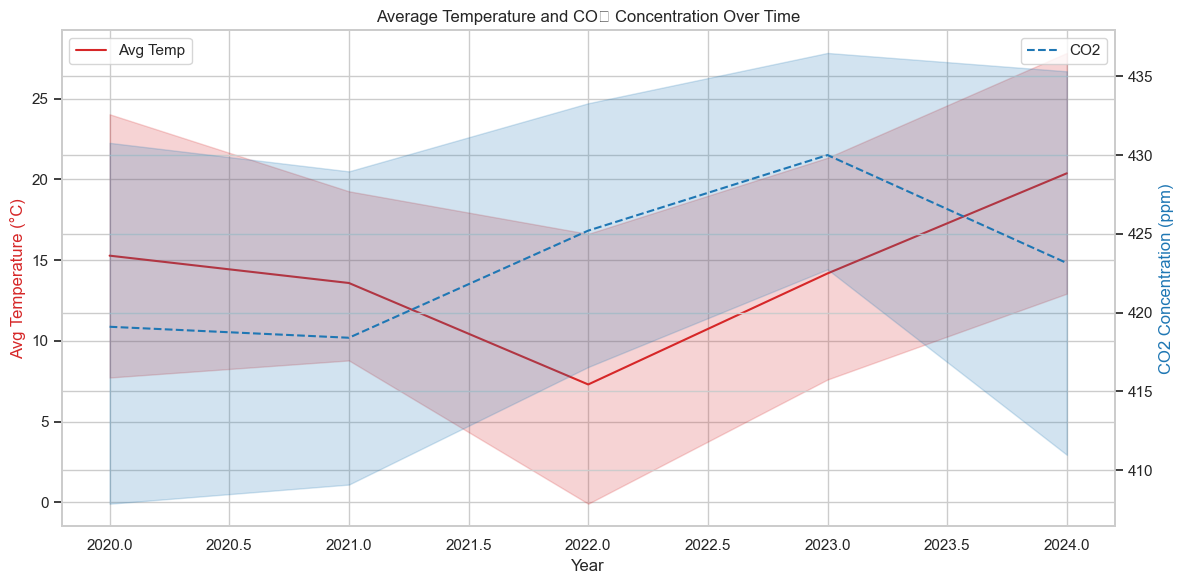

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot 1: Avg Temperature and CO2 Concentration over Years
fig, ax1 = plt.subplots(figsize=(12, 6))

# Twin axis to show two lines with different scales
ax2 = ax1.twinx()
sns.lineplot(data=df_cleaned, x="Year", y="Avg_Temp (°C)", ax=ax1, color="tab:red", label="Avg Temp")
sns.lineplot(data=df_cleaned, x="Year", y="CO2_Concentration (ppm)", ax=ax2, color="tab:blue", label="CO2", linestyle="--")

ax1.set_ylabel("Avg Temperature (°C)", color="tab:red")
ax2.set_ylabel("CO2 Concentration (ppm)", color="tab:blue")
ax1.set_title("Average Temperature and CO₂ Concentration Over Time")

fig.tight_layout()
plt.show()


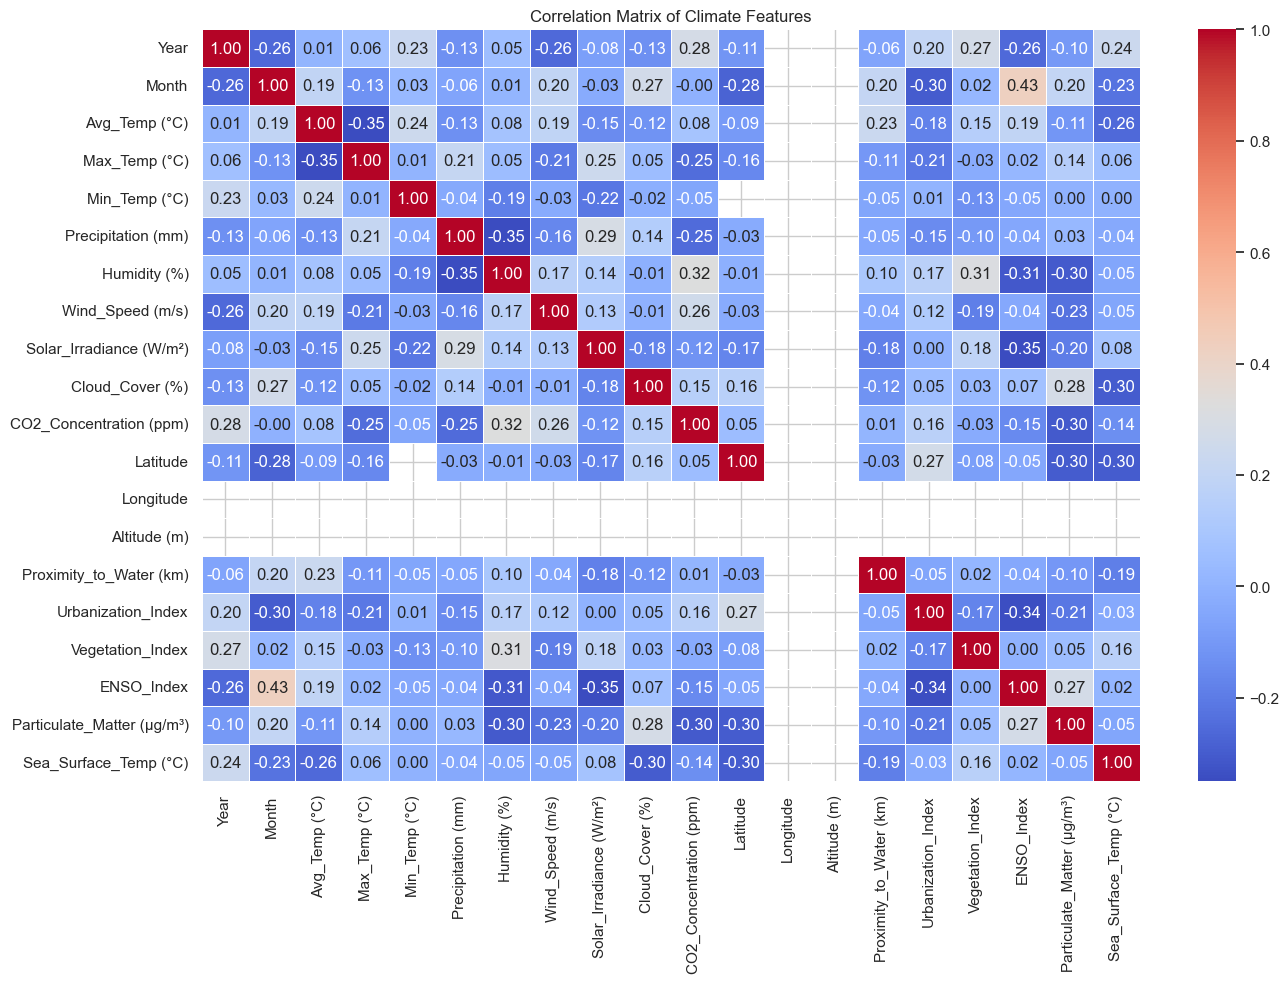

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation_matrix = df_cleaned.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Climate Features")
plt.tight_layout()
plt.show()


In [11]:
target = "Avg_Temp (°C)"
features = df_cleaned.select_dtypes(include="number").drop(columns=[target]).columns

X = df_cleaned[features]
y = df_cleaned[target]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [14]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2


(127.96862061937706, -0.022647379704542336)

In [15]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 127.97
R² Score: -0.02
